In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn xgboost matplotlib seaborn joblib


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE


In [ ]:
data = pd.read_csv("/content/creditcard.csv")

print("Dataset Shape:", data.shape)
data.head()


Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64


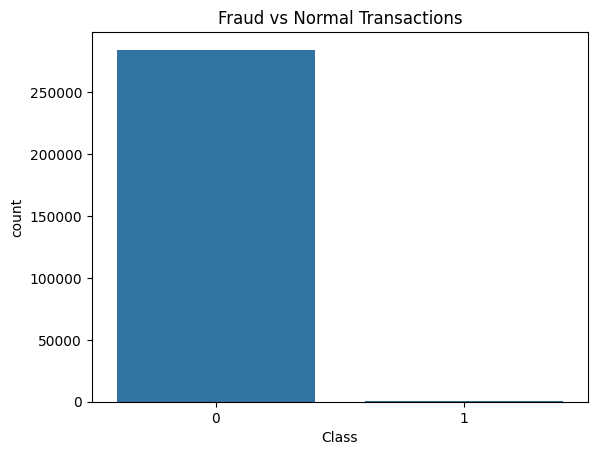

In [ ]:
print(data['Class'].value_counts())

sns.countplot(x=data['Class'])
plt.title("Fraud vs Normal Transactions")
plt.show()


In [ ]:
X = data.drop('Class', axis=1)
y = data['Class']


In [ ]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("After SMOTE:", np.bincount(y_res))


After SMOTE: [284315 284315]


In [ ]:
scaler = StandardScaler()
X_res = scaler.fit_transform(X_res)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)


In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)


In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)


In [ ]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))

print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56750
           1       0.99      0.97      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted

In [ ]:
rf_probs = rf.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test, rf_probs)

print("Random Forest ROC AUC Score:", roc_score)


Random Forest ROC AUC Score: 0.9999987165165454


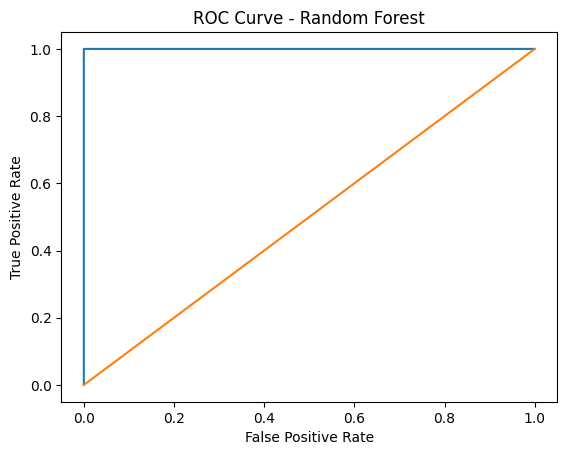

In [ ]:
fpr, tpr, _ = roc_curve(y_test, rf_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


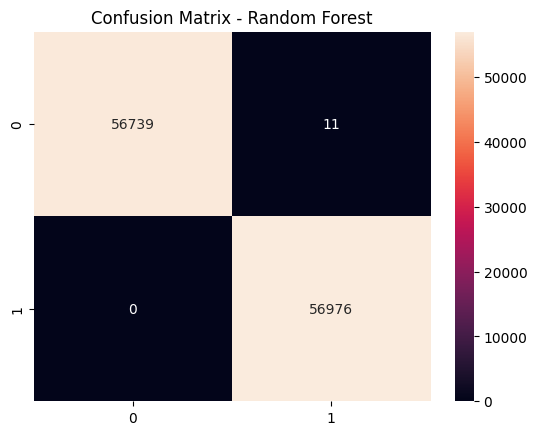

In [ ]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [ ]:
joblib.dump(rf, "fraud_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved Successfully")


Model Saved Successfully


In [ ]:
def predict_fraud(transaction):

    model = joblib.load("fraud_rf_model.pkl")
    scaler = joblib.load("scaler.pkl")

    transaction = scaler.transform([transaction])
    pred = model.predict(transaction)

    if pred[0] == 1:
        return "Fraud Transaction"
    else:
        return "Normal Transaction"


In [ ]:
sample = X.iloc[0].values
print(predict_fraud(sample))


Normal Transaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
